In [ ]:
import pandas as pd

train = pd.read_parquet("Training.parquet")
test = pd.read_parquet("Testing.parquet")

print("Training shape:", train.shape)
print("Testing shape:", test.shape)

display(train.head())

Training shape: (7658, 89)
Testing shape: (3772, 89)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,https://www.todayshomeowner.com/how-to-make-ho...,82,23,0,2,7,0,0,0,0,...,1,1,0,240,8892,67860,0,1,4,legitimate
1,http://thapthan.ac.th/information/confirmation...,93,14,1,2,0,0,0,0,0,...,1,0,1,0,2996,4189860,0,1,2,phishing
2,http://app.dialoginsight.com/T/OFC4/L2S/3888/B...,121,21,1,3,0,0,0,0,0,...,1,1,0,30,2527,346022,0,1,3,phishing
3,https://www.bedslide.com,24,16,0,2,0,0,0,0,0,...,0,0,0,139,7531,1059151,0,0,4,legitimate
4,https://tabs.ultimate-guitar.com/s/sex_pistols...,73,24,0,3,1,0,0,0,0,...,0,0,0,3002,7590,635,0,1,5,legitimate


In [ ]:
print(train.columns.tolist())

['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com', 'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_redirection', 'nb_external_redirection', 'length_words_raw', 'char_repeat', 'shortest_words_raw', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand', 'brand_in_subdomain', 'brand_in_path', 'suspecious_tld', 'statistical_report', 'nb_hyperlinks', 'ratio_intHyperlinks', 'ratio_extHyperlinks', 'ratio_nullHyperlinks', 'nb_extCSS', 'rat

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_url(url):
    url = str(url)

    # remove protocol and www
    url = re.sub(r'https?://|www\.', ' ', url)

    # replace non-alphabetic characters with space
    url = re.sub(r'[^a-zA-Z]', ' ', url)

    # lowercase
    url = url.lower()

    # tokenization using split
    tokens = url.split()

    # remove stopwords and very short tokens
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]

    return " ".join(tokens)

train['cleaned_url'] = train['url'].apply(clean_url)
test['cleaned_url'] = test['url'].apply(clean_url)

train[['url', 'cleaned_url']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,url,cleaned_url
0,https://www.todayshomeowner.com/how-to-make-ho...,todayshomeowner com make homemade insecticidal...
1,http://thapthan.ac.th/information/confirmation...,thapthan ac th information confirmation dpbox ...
2,http://app.dialoginsight.com/T/OFC4/L2S/3888/B...,app dialoginsight com ofc xrko ehc tg vdr npao...
3,https://www.bedslide.com,bedslide com
4,https://tabs.ultimate-guitar.com/s/sex_pistols...,tabs ultimate guitar com sex pistols god save ...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(train['cleaned_url'])
X_test_tfidf = tfidf.transform(test['cleaned_url'])

print("TF-IDF Training Shape:", X_train_tfidf.shape)
print("TF-IDF Testing Shape:", X_test_tfidf.shape)

TF-IDF Training Shape: (7658, 5000)
TF-IDF Testing Shape: (3772, 5000)


In [ ]:
print(train.columns.tolist())

['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com', 'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_redirection', 'nb_external_redirection', 'length_words_raw', 'char_repeat', 'shortest_words_raw', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand', 'brand_in_subdomain', 'brand_in_path', 'suspecious_tld', 'statistical_report', 'nb_hyperlinks', 'ratio_intHyperlinks', 'ratio_extHyperlinks', 'ratio_nullHyperlinks', 'nb_extCSS', 'rat

In [ ]:
print(train['status'].value_counts())
print(test['status'].value_counts())

status
legitimate    3829
phishing      3829
Name: count, dtype: int64
status
phishing      1886
legitimate    1886
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Labels
y_train = train['status']
y_test = test['status']

# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
rf_model.fit(X_train_tfidf, y_train)

# Prediction
rf_pred = rf_model.predict(X_test_tfidf)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8883881230116649

Classification Report:

              precision    recall  f1-score   support

  legitimate       0.86      0.92      0.89      1886
    phishing       0.92      0.86      0.88      1886

    accuracy                           0.89      3772
   macro avg       0.89      0.89      0.89      3772
weighted avg       0.89      0.89      0.89      3772



In [ ]:
# ============================================
# Import Support Vector Machine (SVM) Model
# ============================================

from sklearn.svm import LinearSVC

# ============================================
# Initialize the SVM classifier
# ============================================

svm_model = LinearSVC()

# ============================================
# Train the model using TF-IDF features
# ============================================

svm_model.fit(X_train_tfidf, y_train)

# ============================================
# Predict phishing or legitimate websites
# ============================================

svm_pred = svm_model.predict(X_test_tfidf)

# ============================================
# Calculate accuracy score
# ============================================

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

# ============================================
# Display classification performance metrics
# ============================================

print("\nClassification Report:\n")
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.9029692470837752

Classification Report:

              precision    recall  f1-score   support

  legitimate       0.89      0.92      0.90      1886
    phishing       0.92      0.88      0.90      1886

    accuracy                           0.90      3772
   macro avg       0.90      0.90      0.90      3772
weighted avg       0.90      0.90      0.90      3772



In [ ]:
# ============================================
# Import Decision Tree Classifier
# ============================================

from sklearn.tree import DecisionTreeClassifier

# ============================================
# Initialize Decision Tree Model
# ============================================

dt_model = DecisionTreeClassifier(random_state=42)

# ============================================
# Train the model using TF-IDF features
# ============================================

dt_model.fit(X_train_tfidf, y_train)

# ============================================
# Predict phishing or legitimate websites
# ============================================

dt_pred = dt_model.predict(X_test_tfidf)

# ============================================
# Calculate accuracy score
# ============================================

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

# ============================================
# Display classification performance metrics
# ============================================

print("\nClassification Report:\n")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.8544538706256628

Classification Report:

              precision    recall  f1-score   support

  legitimate       0.84      0.88      0.86      1886
    phishing       0.87      0.83      0.85      1886

    accuracy                           0.85      3772
   macro avg       0.86      0.85      0.85      3772
weighted avg       0.86      0.85      0.85      3772



In [ ]:
# ============================================
# Import AdaBoost Classifier
# ============================================

from sklearn.ensemble import AdaBoostClassifier

# ============================================
# Initialize AdaBoost Model
# ============================================

ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

# ============================================
# Train the model using TF-IDF features
# ============================================

ada_model.fit(X_train_tfidf, y_train)

# ============================================
# Predict phishing or legitimate websites
# ============================================

ada_pred = ada_model.predict(X_test_tfidf)

# ============================================
# Calculate accuracy score
# ============================================

ada_accuracy = accuracy_score(y_test, ada_pred)

print("AdaBoost Accuracy:", ada_accuracy)

# ============================================
# Display classification performance metrics
# ============================================

print("\nClassification Report:\n")
print(classification_report(y_test, ada_pred))

AdaBoost Accuracy: 0.7001590668080594

Classification Report:

              precision    recall  f1-score   support

  legitimate       0.63      0.98      0.77      1886
    phishing       0.95      0.42      0.59      1886

    accuracy                           0.70      3772
   macro avg       0.79      0.70      0.68      3772
weighted avg       0.79      0.70      0.68      3772



In [ ]:
!pip install xgboost

In [ ]:
# ============================================
# Import XGBoost Classifier
# ============================================

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# ============================================
# Encode labels into numeric format
# legitimate = 0
# phishing = 1
# ============================================

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# ============================================
# Initialize XGBoost Model
# ============================================

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# ============================================
# Train the model using TF-IDF features
# ============================================

xgb_model.fit(X_train_tfidf, y_train_encoded)

# ============================================
# Predict phishing or legitimate websites
# ============================================

xgb_pred = xgb_model.predict(X_test_tfidf)

# ============================================
# Calculate accuracy score
# ============================================

xgb_accuracy = accuracy_score(y_test_encoded, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

# ============================================
# Display classification performance metrics
# ============================================

print("\nClassification Report:\n")
print(classification_report(y_test_encoded, xgb_pred))

XGBoost Accuracy: 0.8234358430540827

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.93      0.84      1886
           1       0.91      0.72      0.80      1886

    accuracy                           0.82      3772
   macro avg       0.84      0.82      0.82      3772
weighted avg       0.84      0.82      0.82      3772



In [ ]:
!pip install lightgbm

In [ ]:
# ============================================
# Import LightGBM Classifier
# ============================================

from lightgbm import LGBMClassifier

# ============================================
# Initialize LightGBM Model
# ============================================

lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# ============================================
# Train the model using TF-IDF features
# ============================================

lgbm_model.fit(X_train_tfidf, y_train_encoded)

# ============================================
# Predict phishing or legitimate websites
# ============================================

lgbm_pred = lgbm_model.predict(X_test_tfidf)

# ============================================
# Calculate accuracy score
# ============================================

lgbm_accuracy = accuracy_score(y_test_encoded, lgbm_pred)

print("LightGBM Accuracy:", lgbm_accuracy)

# ============================================
# Display classification performance metrics
# ============================================

print("\nClassification Report:\n")
print(classification_report(y_test_encoded, lgbm_pred))

[LightGBM] [Info] Number of positive: 3829, number of negative: 3829
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.066684 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5981
[LightGBM] [Info] Number of data points in the train set: 7658, number of used features: 268
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Accuracy: 0.8438494167550371

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1886
           1       0.87      0.81      0.84      1886

    accuracy                           0.84      3772
   macro avg       0.85      0.84      0.84      3772
weighted avg       0.85      0.84      0.84      3772



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


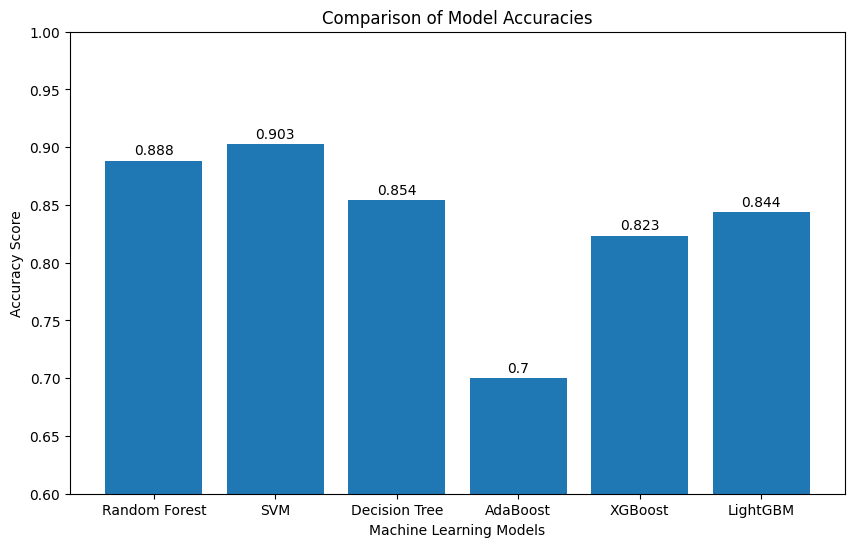

In [ ]:
# ============================================
# Import visualization libraries
# ============================================

import matplotlib.pyplot as plt

# ============================================
# Store model names and accuracies
# ============================================

models = [
    'Random Forest',
    'SVM',
    'Decision Tree',
    'AdaBoost',
    'XGBoost',
    'LightGBM'
]

accuracies = [
    rf_accuracy,
    svm_accuracy,
    dt_accuracy,
    ada_accuracy,
    xgb_accuracy,
    lgbm_accuracy
]

# ============================================
# Create accuracy comparison graph
# ============================================

plt.figure(figsize=(10,6))

bars = plt.bar(models, accuracies)

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy Score")
plt.title("Comparison of Model Accuracies")

# Show accuracy values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.005,
        round(yval, 3),
        ha='center'
    )

plt.ylim(0.6, 1.0)

plt.savefig("model_accuracy_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

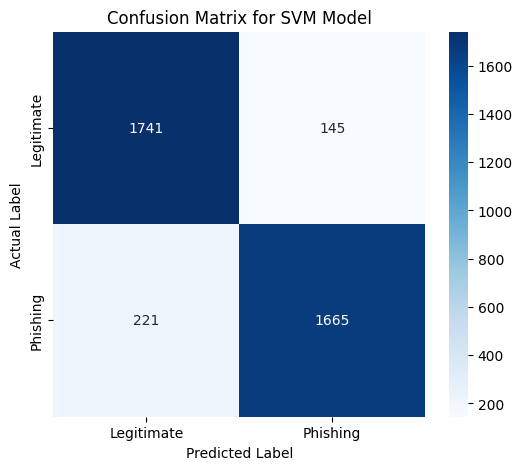

In [ ]:
# ============================================
# Import libraries
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ============================================
# Create confusion matrix
# ============================================

cm = confusion_matrix(y_test, svm_pred)

# ============================================
# Plot confusion matrix
# ============================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Legitimate', 'Phishing'],
    yticklabels=['Legitimate', 'Phishing']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix for SVM Model")

# Save figure
plt.savefig("svm_confusion_matrix.png", dpi=300, bbox_inches='tight')

plt.show()